# Machine Learning Project - Week 2
## Data Pre-processing and Exploratory Data Analysis (EDA)
**Dataset:** Vehicle Insurance Fraud (`insurance_fraud_data.csv`)

This notebook demonstrates the step-by-step process of cleaning and preparing our data for machine learning models, following the Week 2 SOP guidelines.

### Step 1: Load the CSV Dataset
We will load the dataset using the Pandas library.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv('insurance_fraud_data.csv')

### Step 2: Initial Exploration
We inspect the first 5 rows, dataset info (columns and types), and its initial shape.

In [3]:
# Display the first 5 rows of the dataset
print(" FIRST 5 ROWS ")
print(df.head())

# Display column information and types
print("\n DATASET INFO ")
df.info()

# Display the total number of rows and columns
print("\n DATASET SHAPE ")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

 FIRST 5 ROWS 
   claim_number  age_of_driver gender marital_status  safety_rating  \
0        414724             39      M              1             73   
1        269568             33      M              1             72   
2        974592             31      M              1             76   
3        995328             53      F              1             93   
4       1140480             41      M              1             87   

   annual_income  high_education  address_change property_status  zip_code  \
0        58612.8               1               0             Own     50048   
1        35936.0               0               1             Own     50006   
2        84940.8               1               1             Own     15021   
3        73526.4               0               1             Own     85027   
4        59403.2               1               0             Own     80046   

   ... vehicle_category vehicle_price vehicle_color  total_claim injury_claim  \
0  ...  

### Step 3: Clean Column Names
We will remove any extra spaces in column names, convert them to lowercase, and replace spaces with underscores.

In [4]:
# Remove leading/trailing spaces, convert to lowercase, and replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['claim_number', 'age_of_driver', 'gender', 'marital_status', 'safety_rating', 'annual_income', 'high_education', 'address_change', 'property_status', 'zip_code', 'claim_date', 'claim_day_of_week', 'accident_site', 'past_num_of_claims', 'witness_present', 'liab_prct', 'channel', 'police_report', 'age_of_vehicle', 'vehicle_category', 'vehicle_price', 'vehicle_color', 'total_claim', 'injury_claim', 'policy_deductible', 'annual_premium', 'days_open', 'form_defects', 'fraud_reported']


### Step 4: Fix Incorrect Data Types
Some columns contain '*' characters, causing Pandas to load them as objects (strings). We will convert these columns to numeric (coercing '*' to NaN) and convert the date column to a proper datetime format.

In [5]:
# Convert columns containing '*' to numeric (errors='coerce' turns '*' to NaN)
df['marital_status'] = pd.to_numeric(df['marital_status'], errors='coerce')
df['witness_present'] = pd.to_numeric(df['witness_present'], errors='coerce')
df['age_of_vehicle'] = pd.to_numeric(df['age_of_vehicle'], errors='coerce')
df['injury_claim'] = pd.to_numeric(df['injury_claim'], errors='coerce')

# Convert claim_date to datetime format
df['claim_date'] = pd.to_datetime(df['claim_date'], errors='coerce')
print("Converted data types successfully!")

Converted data types successfully!


### Step 5: Handle Missing Values
We will fill missing values (NaN) in numerical columns with their median, and date/categorical columns with their mode.

In [6]:
# Display number of missing values in each column
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing values in numerical columns with their median
df['marital_status'] = df['marital_status'].fillna(df['marital_status'].median())
df['witness_present'] = df['witness_present'].fillna(df['witness_present'].median())
df['age_of_vehicle'] = df['age_of_vehicle'].fillna(df['age_of_vehicle'].median())
df['injury_claim'] = df['injury_claim'].fillna(df['injury_claim'].median())

# Fill missing values in claim_date with the most common date (mode)
df['claim_date'] = df['claim_date'].fillna(df['claim_date'].mode()[0])

# Fill missing values in categorical columns with the mode
df['fraud_reported'] = df['fraud_reported'].fillna(df['fraud_reported'].mode()[0])

print("\nMissing values remaining:", df.isnull().sum().sum())

Missing values before imputation:
marital_status      2
claim_date         14
witness_present    88
age_of_vehicle      3
injury_claim       14
fraud_reported      8
dtype: int64

Missing values remaining: 0


### Step 6: Remove Duplicate Rows
We check for and drop duplicate rows in the dataset.

In [7]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows: 0


### Step 7: Detect and Remove Outliers using IQR
We will remove outliers from continuous numerical columns using the Interquartile Range (IQR) method.

In [8]:
# List of continuous numerical columns to filter
continuous_cols = ['age_of_driver', 'safety_rating', 'annual_income', 'vehicle_price', 'total_claim', 'injury_claim', 'annual_premium', 'days_open', 'form_defects']

# Remove outliers step-by-step
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out values outside bounds
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (7640, 29)


### Step 8a: Generate Histograms
We plot histograms to see the data distribution of important numerical features.

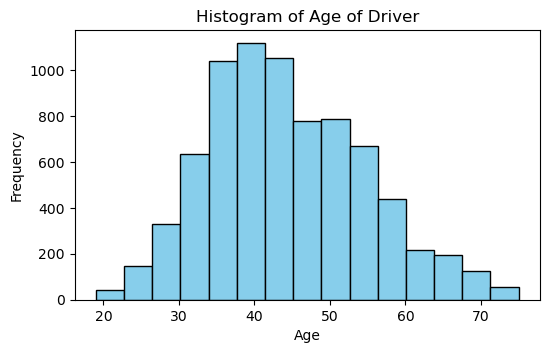

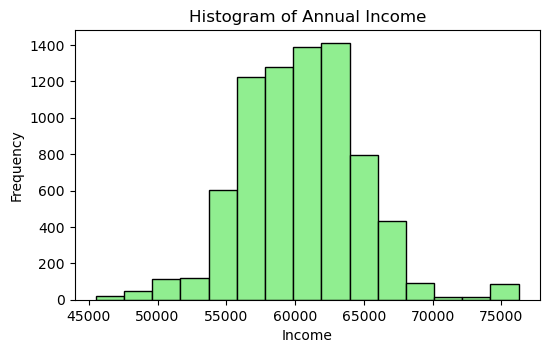

In [9]:
# Histogram for Age of Driver
plt.figure(figsize=(6, 3.5))
plt.hist(df['age_of_driver'], bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of Age of Driver')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Histogram for Annual Income
plt.figure(figsize=(6, 3.5))
plt.hist(df['annual_income'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Histogram of Annual Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

### Step 8b: Generate Box Plots
We plot box plots to visualize the spread and check if outliers have been handled.

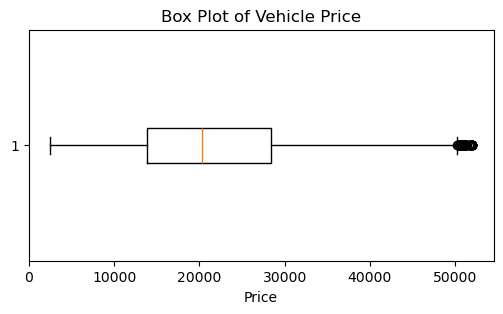

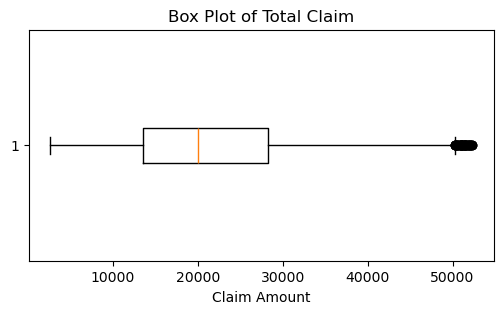

In [10]:
# Box plot for Vehicle Price
plt.figure(figsize=(6, 3))
plt.boxplot(df['vehicle_price'], vert=False)
plt.title('Box Plot of Vehicle Price')
plt.xlabel('Price')
plt.show()

# Box plot for Total Claim
plt.figure(figsize=(6, 3))
plt.boxplot(df['total_claim'], vert=False)
plt.title('Box Plot of Total Claim')
plt.xlabel('Claim Amount')
plt.show()

### Step 8c: Generate Bar Charts
We plot bar charts for key categorical variables to see count comparisons.

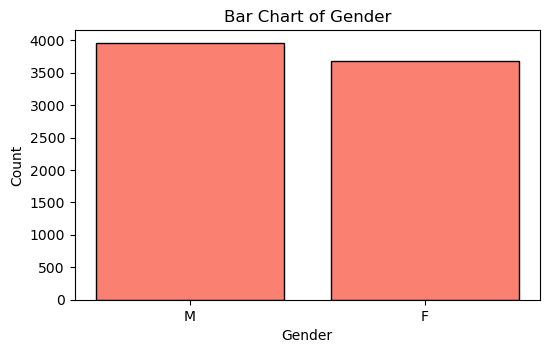

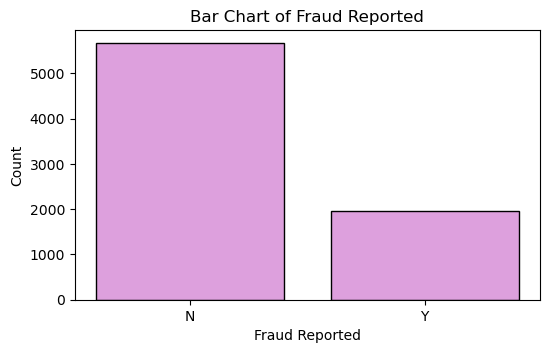

In [11]:
# Bar chart for Gender
plt.figure(figsize=(6, 3.5))
gender_counts = df['gender'].value_counts()
plt.bar(gender_counts.index.astype(str), gender_counts.values, color='salmon', edgecolor='black')
plt.title('Bar Chart of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Bar chart for Fraud Reported (Target)
plt.figure(figsize=(6, 3.5))
fraud_counts = df['fraud_reported'].value_counts()
plt.bar(fraud_counts.index.astype(str), fraud_counts.values, color='plum', edgecolor='black')
plt.title('Bar Chart of Fraud Reported')
plt.xlabel('Fraud Reported')
plt.ylabel('Count')
plt.show()

### Step 9: Date Feature Extraction
Since machine learning models cannot process date strings directly, we extract Year, Month, and Day features, and drop the original date column.

In [12]:
# Extract features from datetime
df['claim_year'] = df['claim_date'].dt.year
df['claim_month'] = df['claim_date'].dt.month
df['claim_day'] = df['claim_date'].dt.day

# Drop original claim_date column
df = df.drop(columns=['claim_date'])
print("Extracted date features and dropped original date column.")

Extracted date features and dropped original date column.


### Step 10: Encode Categorical Columns
We use LabelEncoder to convert categorical text columns into numeric codes (0, 1, 2...).

In [13]:
# List of categorical columns to encode
categorical_cols = ['gender', 'property_status', 'claim_day_of_week', 'accident_site', 'channel', 'vehicle_category', 'vehicle_color', 'fraud_reported']

# Label Encode each column
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print("Label encoded categorical columns:", categorical_cols)

Label encoded categorical columns: ['gender', 'property_status', 'claim_day_of_week', 'accident_site', 'channel', 'vehicle_category', 'vehicle_color', 'fraud_reported']


### Step 11: Scale Numerical Columns
We scale numerical columns using StandardScaler to bring them onto the same scale (mean=0, variance=1).

In [14]:
# List of numerical columns to scale (excluding ID and target)
columns_to_scale = ['age_of_driver', 'safety_rating', 'annual_income', 'vehicle_price', 'total_claim', 'injury_claim', 'annual_premium', 'days_open', 'form_defects', 'claim_year', 'claim_month', 'claim_day']

# Apply StandardScaler
scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
print("Standardized numerical columns successfully!")

Standardized numerical columns successfully!


### Step 12: Cleaned Dataset and Final Shape
We display the head of the preprocessed dataset and its final shape.

In [15]:
# Display head and final shape
print("--- CLEANED DATASET HEAD ---")
print(df.head())

print("\n--- FINAL DATASET SHAPE ---")
print(df.shape)

--- CLEANED DATASET HEAD ---
    claim_number  age_of_driver  gender  marital_status  safety_rating  \
0         414724      -0.514023       1             1.0      -0.166104   
3         995328       0.823460       0             1.0       1.342320   
4        1140480      -0.322954       1             1.0       0.889793   
9        2198016       0.441322       0             0.0      -1.372844   
10       2322432       2.447547       1             1.0      -1.297423   

    annual_income  high_education  address_change  property_status  zip_code  \
0       -0.438104               1               0                0     50048   
3        3.057098               0               1                0     85027   
4       -0.252863               1               0                0     80046   
9        0.413854               1               0                0     80015   
10       1.757413               1               0                0     20158   

    ...  total_claim  injury_claim  policy_de